<a href="https://colab.research.google.com/github/HaileyZweedyk/data-mining-assignments/blob/main/CIS335Assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##CIS335 Assignment 1



**Data Analysis for a Winery.**

**Dataset Attributes:** Dataset contains various physiochemical properties of wine and how it affects quality ratings.

**Goal of Analysis:** Provide detailed answer to the CEO's questions including visualzations, statistical summaries, and actionable insights


##Import Dataset

The dataset file is WineQT.csv

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving WineQT.csv to WineQT.csv


##Installations

Includes all pip installations to import Python modules

In [ ]:
!pip install numpy pandas matplotlib seaborn

##Python Imports

Includes all Python API imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##Define Dataframe

Takes the dataset and transforms it into a Pandas dataframe to be used throughout the analysis

In [ ]:
df = pd.read_csv('WineQT.csv')
df.dropna()
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595


##Question 1

**What are they key characteristics of the wine in this dataset?**

Code Steps:

1. Perform statistical summary of several numeric attributes (Alcohol, pH, Chlorides, Fixed Acidity, Residual Sugar)
2. Present mean, median, Q1, and Q3 as a table
3. Describe centeral tendencies and spread of these attributes

In [ ]:
statAttr = ['alcohol', 'pH', 'chlorides', 'fixed acidity', 'residual sugar']

# 1. Perform statistical summary
summary = (
    df[statAttr]
    .describe()
    .loc[["mean", "50%", "25%", "75%"]]
    .rename(index={"mean": "Mean", "50%": "Median", "25%": "Q1", "75%": "Q3"
    })
)

# 2. Print summary as table
print(f"{summary} + \n\n")

# 3. Describe centeral tendencies and spread
var = df[statAttr].var()
std = df[statAttr].std()
print(f"Variance:\n{var}\n\n")
print(f"Standard Deviation:\n{std}")




          alcohol        pH  chlorides  fixed acidity  residual sugar
Mean    10.442111  3.311015   0.086933       8.311111        2.532152
Median  10.200000  3.310000   0.079000       7.900000        2.200000
Q1       9.500000  3.205000   0.070000       7.100000        1.900000
Q3      11.100000  3.400000   0.090000       9.100000        2.600000 + 


Variance:
alcohol           1.171147
pH                0.024544
chlorides         0.002234
fixed acidity     3.054088
residual sugar    1.838512
dtype: float64


Standard Deviation:
alcohol           1.082196
pH                0.156664
chlorides         0.047267
fixed acidity     1.747595
residual sugar    1.355917
dtype: float64


##Question 2

**Are there any outliers in the wine's attributes?**

Code Steps:
1. Identify outliers for 1 attribute (Fixed Acidity) using IQR (Q3 - Q1)
2. Visualize

Q1: 7.1
Q3: 9.1


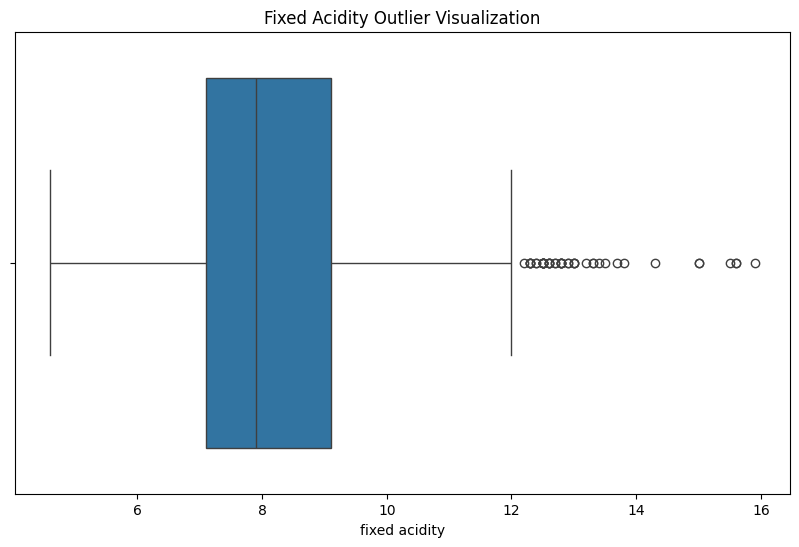



Fixed Acidity Outliers:

145    12.8
146    12.8
170    15.0
171    15.0
188    12.5
211    13.3
234    13.4
240    12.5
244    13.8
248    13.5
254    12.6
258    12.5
259    12.8
260    12.8
272    13.7
279    12.2
284    12.5
301    12.8
304    12.3
306    12.3
310    12.6
311    15.6
313    12.5
332    13.0
334    12.5
361    13.3
367    12.5
382    12.9
388    14.3
392    12.4
397    15.5
399    15.6
400    13.0
401    12.7
404    13.0
405    12.7
415    12.3
416    12.3
425    12.4
433    13.2
462    15.9
584    12.9
586    12.6
864    12.6
Name: fixed acidity, dtype: float64


In [ ]:
# 1. Outlier calculations

print(f"Q1: {df['fixed acidity'].quantile(0.25)}")
print(f"Q3: {df['fixed acidity'].quantile(0.75)}")

# Q3 - Q1
IQR = df['fixed acidity'].quantile(0.75) - df['fixed acidity'].quantile(0.25)

# lower = Q1 - IQR * 1.5; upper = Q3 + IQR * 1.5
lower_bound = df['fixed acidity'].quantile(0.25) - (IQR * 1.5)
upper_bound = df['fixed acidity'].quantile(0.75) + (IQR * 1.5)

# Outliers
outlier_calc = (df["fixed acidity"] < lower_bound) | (df["fixed acidity"] > upper_bound)
outliers = df.loc[outlier_calc, "fixed acidity"]
# 2. Visualize

# Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['fixed acidity'])
plt.title('Fixed Acidity Outlier Visualization')
plt.show()

# List of Outliers
print(f"\n\nFixed Acidity Outliers:\n\n{outliers}")



##Question 3

**What relationships exist between the attributes and wine quality?**

Code Steps:
1. Use scatterplots to analyze correlation between three attributes (Alcohol, Fixed Acidity, pH) and the quality score
2. identify any positive, negative, or no correlation

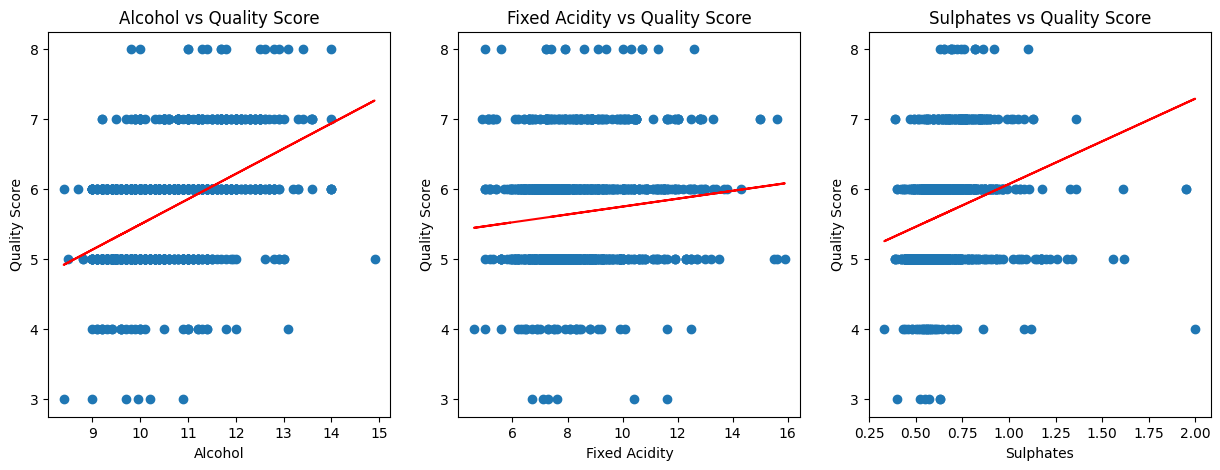

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# Alcohol vs Quality Score
m_alc, b_alc = np.polyfit(df['alcohol'], df['quality'], 1)

ax[0].scatter(df['alcohol'], df['quality'])

# Regression Line - Show Correlation
ax[0].plot(df['alcohol'], m_alc*df['alcohol'] + b_alc, color='red')

ax[0].set_title('Alcohol vs Quality Score')
ax[0].set_xlabel('Alcohol')
ax[0].set_ylabel('Quality Score')


# Fixed Acidity vs Quality Score
m_acid, b_acid = np.polyfit(df['fixed acidity'], df['quality'], 1)

ax[1].scatter(df['fixed acidity'], df['quality'])

# Regression Line - Show Correlation
ax[1].plot(df['fixed acidity'], m_acid*df['fixed acidity'] + b_acid, color='red')

ax[1].set_title('Fixed Acidity vs Quality Score')
ax[1].set_xlabel('Fixed Acidity')
ax[1].set_ylabel('Quality Score')


# pH vs Quality Score
m_pH, b_pH = np.polyfit(df['sulphates'], df['quality'], 1)

ax[2].scatter(df['sulphates'], df['quality'])

# Regression Line - Show Correlaton
ax[2].plot(df['sulphates'], m_pH*df['sulphates'] + b_pH, color='red')

ax[2].set_title('Sulphates vs Quality Score')
ax[2].set_xlabel('Sulphates')
ax[2].set_ylabel('Quality Score')
plt.show()


##Question 4

**How do the distributions of key attributes compare?

Code Steps:

1. Create boxplots for three numeric values (Alcohol, Sulphates, Fixed Acidity) and compare distributions

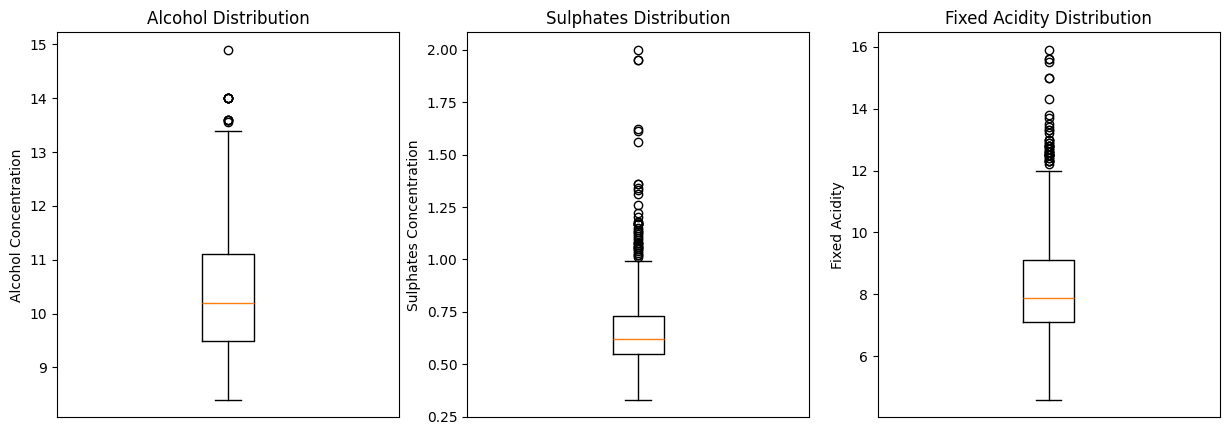

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# Alcohol
ax[0].boxplot(df['alcohol'])
ax[0].set_title('Alcohol Distribution')
ax[0].set_ylabel('Alcohol Concentration')
ax[0].set_xticks([])

# Sulphates
ax[1].boxplot(df['sulphates'])
ax[1].set_title('Sulphates Distribution')
ax[1].set_ylabel('Sulphates Concentration')
ax[1].set_xticks([])

# Fixed Acidity
ax[2].boxplot(df['fixed acidity'])
ax[2].set_title('Fixed Acidity Distribution')
ax[2].set_ylabel('Fixed Acidity')
ax[2].set_xticks([])

plt.show()